<a href="https://colab.research.google.com/github/Dogyun-Kim57/AI_26/blob/main/06_03_%EC%A3%BC%EC%84%B1%EB%B6%84%EB%B6%84%EC%84%9D(%EC%95%95%EC%B6%95%EA%B8%B0%EB%B2%95).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 사진이나 이미지 동영상 등은 대체적으로 용량이 커서 보관하기 힘들기 때문에...
# 주성분만 분석해서 가지고 있으면 디스크 용량 등에 이로움이 있다. ( 차원 축소 알고리즘 )
# 데이터가 가진 속성을 특성이라고 함! ( 사진의 특성 : R: 빨강색, G: 녹색, B: 파랑색, K: 검은색(B가 파랑으로 분류되기 때문에 K로 씀), A: 필터 )
# -> 과일 사진의 경우 10,000개의 픽셀이 있기 때문에 10,000개의 특성이 있다. ( 줄이지 않으면 5만개..? )
# -> 차원(dimension : 디멘션 )

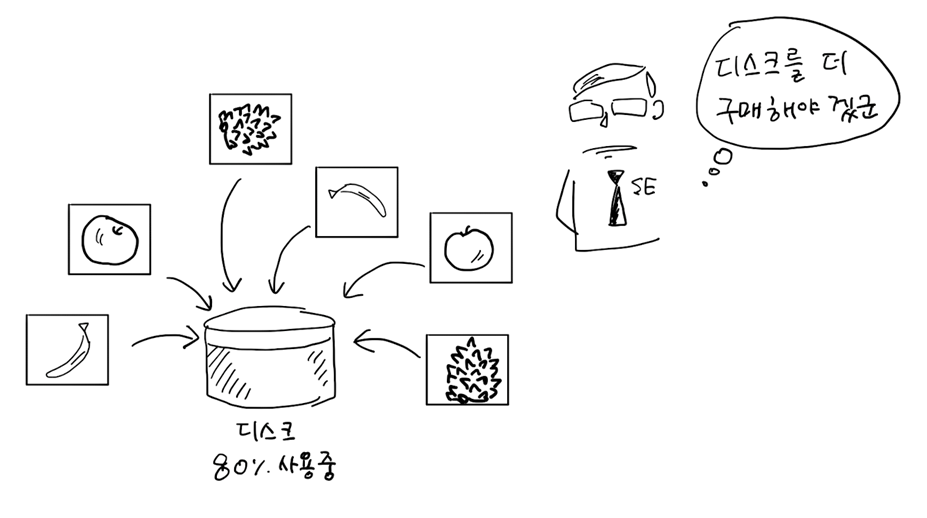

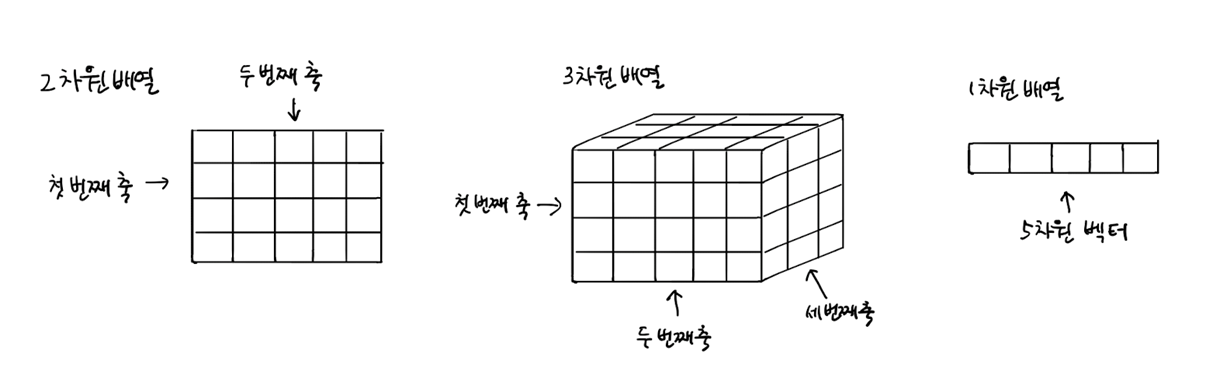

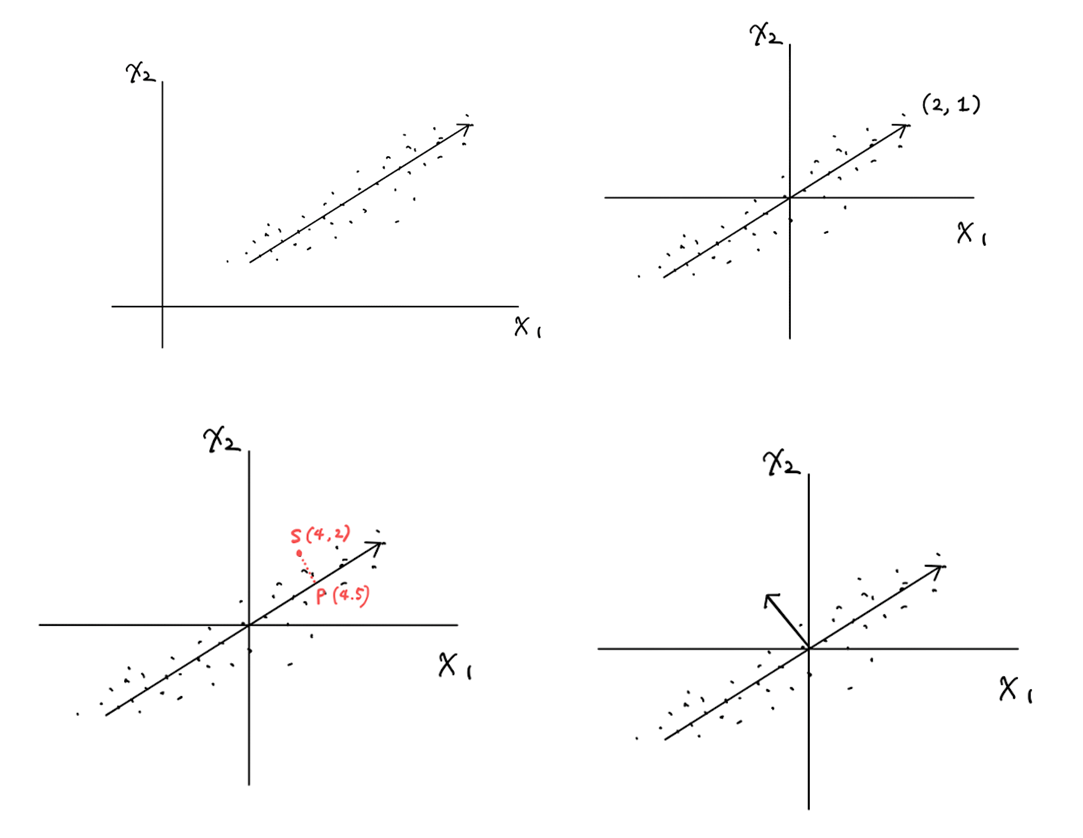

In [2]:
# 특성이 많을수록 선형 모델의 성능이 높아지고 훈련 데이터에 쉽게 과대적합 된다.

# 차원축소 : 데이터를 가장 잘 나타내는 '일부 특성'을 선택함.
# 이를 사용하는 이유는 데이터의 크기를 줄이고 지도 학습 모델의 성능을 향상시키기 위해!

# 주성분 분석(PCA : Principal Component Analysis)
# PCA : 줄어든 차원에서 다시 원본 차원으로 손실을 최대한 줄이면서 복원할 수도 있어야 함
# 참조 : https://ddongwon.tistory.com/114

# 주성분 분석은 데이터에 있는 분산이 큰 방향을 찾는것으로 이해(분산 : 데이터가 널리 퍼져있는 정도)
# -> 데이터를 잘 표현하는 벡터?

!wget https://bit.ly/fruits_300_data -O fruits_300.npy

--2026-03-03 06:37:15--  https://bit.ly/fruits_300_data
Resolving bit.ly (bit.ly)... 67.199.248.10, 67.199.248.11
Connecting to bit.ly (bit.ly)|67.199.248.10|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy [following]
--2026-03-03 06:37:15--  https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy [following]
--2026-03-03 06:37:16--  https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... conne

In [6]:
import numpy as np

fruits = np.load('fruits_300.npy')              # 과일 사진 300장 그리고 100가로 픽셀 * 100세로 픽셀 데이터를 fruits 변수에 넣음.
fruits_2d = fruits.reshape(-1, 100*100)         # 300장 사진의 가로픽셀과 세로픽셀을 곱하여 10,000으로 변환 ( 2차원으로 변환 )

from sklearn.decomposition import PCA           # 주성분 분석 알고리즘 사용
# 사이킷런의 decomposition 모듈 안의 PCA 클래스를 사용함

pca = PCA(n_components=50)                     # PCA 클래스를 만들 때, 주 성분의 갯수를 지정! 300개가 50개로 압축됨!
pca.fit(fruits_2d)                             # 비지도 학습임으로 타겟 제외 학습!

PCA(n_components=50)

In [7]:
# 확인하기
print(pca.components_.shape)                  # components_ 주 성분이 들어있는 속성 50개로 압축됨!
# 50개의 속성에 10000개의(100x100해상도) 특성 개수

(50, 10000)


In [12]:
# 원본을 축소하기 전 데이터 확인하기
print(fruits_2d.shape)

(300, 10000)


In [19]:
# 이미지 출력하기

import matplotlib.pyplot as plt

# 이미지 출력용 메서드! 가로 10개의 이미지 배열을 만들고 10개가 넘어가면 다음줄에 10개!
def draw_fruits(arr, ratio=1):            # 배열의 값을 이용해서 이미지로 출력해주는 메서드
    n = len(arr)                          # n은 샘플 갯수!

# 한 줄에 10개의 이미지를 그리고 싶을때! 샘플 개수를 10으로 나누어 전체 행 개수를 계산한다.
    rows = int(np.ceil(n/10))

# 행이 1개이면 열의 개수는 샘플의 개수로 하고, 그렇지 않으면 10개이다.
    cols = n if rows < 2 else 10
    fig, axs = plt.subplots(rows, cols,
                            figsize=(cols * ratio, rows * ratio), squeeze=False)

    for i in range(rows):
        for j in range(cols):
            if i*10 + j < n:              # n개 까지만 그린다.
                axs[i, j].imshow(arr[i*10 + j], cmap='gray_r')
            axs[i, j].axis('off')

    plt.show()

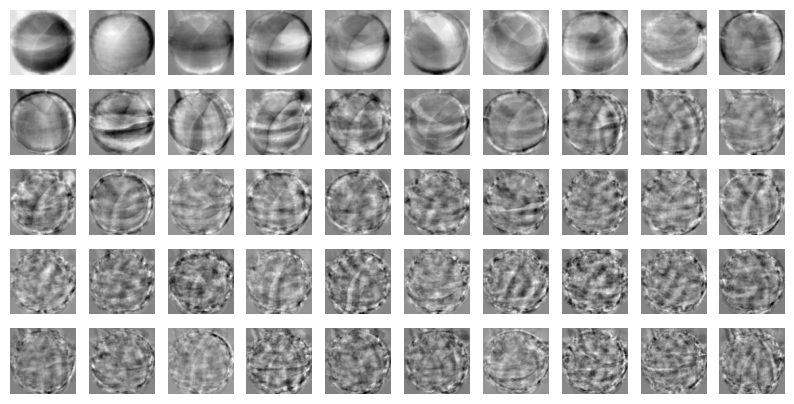

In [20]:
draw_fruits(pca.components_.reshape(-1, 100, 100)) # 10 * 5 = 50
# 주성분은 원본 데이터를 투영하여 특성의 개수를 만들어 냄
# 이 주성분은 원본 데이터에서 가장 분산이 큰 방향을 순서대로 나타낸 것
# 데이터셋에 있는 어떤 특징을 잡아낸 것 처럼 생각해도 됨

In [23]:
# 주성분 분석을 이용하여 300개의 사진을 50개로 줄여보았다.   ( 결과는 매우 이상한 물체가 출력됨; )
# 이번에는 원본 데이터의 특성의 개수를 10,000개에서 50개로 줄여보자.
# -> 원본의 분해

# transform()메서드를 사용하여 원본 데이터의 차원(특성)을 줄여본다.
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape) # 차원축소된 데이터 (300, 50) -> 저장용량 축소됨
print(fruits_2d.shape)  # 원본데이터 (300, 10000)

(300, 50)
(300, 10000)


In [28]:
# 10000개의 특성을 50개로 줄였으니 어느정도의 손실이 발생할 수 있다.
# 하지만 최대한 분산이 큰 방향으로 데이터를 투영했기 때문에..
# 원본 데이터를 상당 부분 재구성하는것이 가능하다. ( 복구 )
# 원본 데이터의 재구성 -> inverse_transform()
fruits_inverse = pca.inverse_transform(fruits_pca)      # 원본처럼 재구성
print(fruits_inverse.shape)

(300, 10000)


In [ ]:
fruits_reconstruct = fruits_inverse.reshape(-1, 100, 100)           # 모든 객체 300개 100x100 픽셀 (reconstruct =  재구성하다.)
for start in [0, 100, 200]:
    draw_fruits(fruits_reconstruct[start:start+100])
    print("\n")

In [30]:
# 거의 모든 파일이 잘 복원된 듯 보임.
# 특징을 잘 찾아낸것 같고, 물론 일부는 흐리고 번진 부분도 있지만...
# 이건 중요한 특성은 아님!
# 불과 50개의 특성을 10,000개로 늘린 것을 감안한다면 성공적으로 보인다.
# 만약 주 성분을 최대로 사용했다면 완벽하게 원본 데이터를 재구성 할 수 있을 것이다.
# 50개의 특성은 얼마나 분산을 보존하고 있을까를 알아보자.

# 설명된 분산(explained variance) : 주 성분이 원본 데이터의 분산을 얼마나 잘 나타내는지 기록한 값
# PCA 클래스의 explained_variance_ratio 에 주성분의 설명된 분산 비율이 기록되어 있음
# 첫번째 주성분의 설명된 분산이 가장 큼
# 이 분산 비율을 모두 더하면 50개의 주성분으로 표현하고 있는 총 분산 비율
print(np.sum(pca.explained_variance_ratio_))
# 92%가 넘는 분산을 유지하고 있음 ( 이미지 품질 )

0.9215223965827296


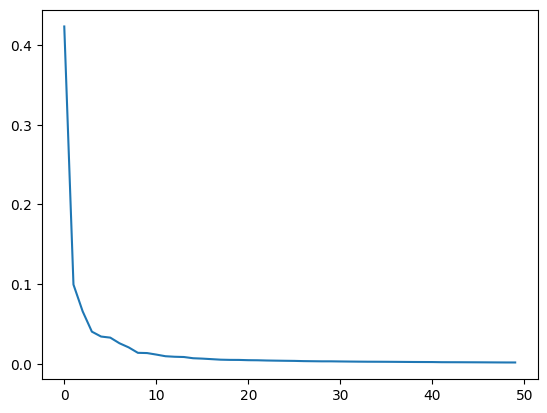

In [31]:
plt.plot(pca.explained_variance_ratio_)

In [ ]:
# 위에 만든 주성분으로 지도 학습 모델에 적용 해보자.
# 전에 사용했던 로지스틱 회귀 모델을 사용!

from sklearn.linear_model import LogisticRegression
# 사이킷런의 로지스틱 클래스

lr = LogisticRegression()

# 지도학습 모델을 사용하기 위해 타겟을 생성한다.
# 사과 = 0, 파인애플 = 1, 바나나 = 2
target = np.array([0] * 100 + [1] * 100 + [2] * 100)        # 정답 파일 생성 ( 타겟 생성 )
# 파이썬 리스트에 정수를 곱하면 리스트 안의 원소를 정수만큼 반복함
# 100개의 0, 100개의 1, 100개의 2로 이루어진 타깃 데이터를 만듬


In [34]:
from sklearn.model_selection import cross_validate          # cross_validate = 크로스 검증

scores = cross_validate(lr, fruits_2d, target )             # fruits_2d 원본 데이터를 사용해 봄 (10,000 픽셀)
print(np.mean(scores['test_score']))                        # 99%의 결과 ( 과대적합! )
# 특성이 10,000개나 되기 때문에 300개의 샘플에서는 과대적합 모델이 됨
print(np.mean(scores['fit_time']))        # 1.57초 정도 걸림!

0.9966666666666667
1.5701303958892823


In [35]:
scores = cross_validate(lr, fruits_pca, target)            # fruits_pca      PCA로 축소한 자료사용 50픽셀
print(np.mean(scores['test_score']))                       # 마찬가지로 99%의 과대 적합 - > 위와 동일
print(np.mean(scores['fit_time']))                         # 하지만 훈련시간은 0.04초로 크게 단축됨

# < 결론 >
# 훈련 속도가 빠르고 용량도 적다.
# PCA로 훈련 데이터의 차원을 축소하면 저장공간과 시간을 절약할 수 있다.

0.9966666666666667
0.04401583671569824


In [36]:
# 앞에서는 PCA클래스를 사용할 때 n_components 매개변수에 주성분 개수를 50개로 진행해보았다.
# 이 대신 비율로 줄일 수도 있다. 50%에 달하는 주성분을 찾도록 분석을 해본다!

pca = PCA(n_components=0.5)        # 주성분 개수 대신 0~1 사이의 실수로 입력
pca.fit(fruits_2d)

PCA(n_components=0.5)

In [38]:
print(pca.n_components_)

# 10,000개의 특성을 2개로 압축해버렸다!
# 2개의 주성분으로 2개의 특성만으로 원본 데이터의 분산 50%를 표현할 수 있다.

2


In [39]:
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)          # 300개의 요소에 2개의 주성분

(300, 2)


In [ ]:
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))           # 99% 과대 적합
print(np.mean(scores['fit_time']))             # 0.03초로 훈련시간이 좀 더 향상

############################ 로지스틱회귀 + PCA 끝 ############################

In [41]:
from sklearn.cluster import KMeans
# 차원 축소된 데이터를 사용하여 K- 평균 알고리즘으로 클러스터를 찾아봄
km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_pca)                # 훈련 데이터를 PCA로 주성분 분석한 자료를 활용 ( 300, 2 )
print(fruits_pca.shape)

(300, 2)


In [42]:
# 전에 있던 값과 PCA로 만든 값 비교!
print(np.unique(km.labels_, return_counts=True))

# 전에 있던 값 = (array([0, 1, 2], dtype=int32), array([112,  98,  90]))
# PCA를 사용한 값 = (array([0, 1, 2], dtype=int32), array([110,  99,  91]))

(array([0, 1, 2], dtype=int32), array([110,  99,  91]))


In [ ]:
# KMeans가 찾은 레이블을 사용해 과일 이미지를 출력해보기!

for label in range(0, 3):
    draw_fruits(fruits[km.labels_ == label])
    print("\n")

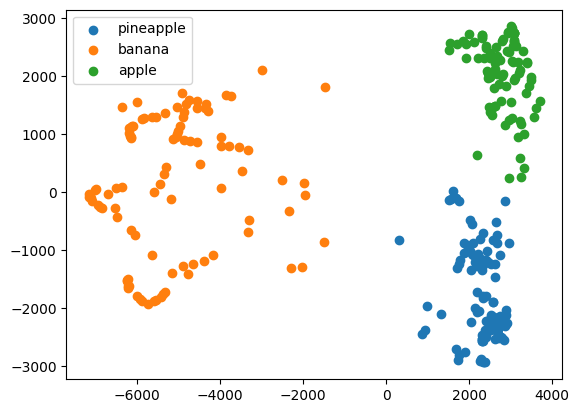

In [44]:
# 훈련 데이터의 차원을 줄이면 또 하나 얻을 수 있는 장점은 시각화가 가능하다는 것이다.
# 3개 이하로 차원을 줄이면 화면에 출력하기가 비교적 쉬워진다.
# fruits_pca 데이터가 2개의 특성으로 있기 때문에 2차원으로 표현이 가능하다.


# km.lebels_ 를 사용하여 클러스터 별로 나누어 산점도를 그린다.
for label in range(0, 3):
    data = fruits_pca[km.labels_ == label]

    plt.scatter(data[:,0], data[:,1])

plt.legend(['pineapple', 'banana', 'apple'])            # 범례 표시

plt.show()